# AGRICULTURAL YIELD PREDICTION


# 1. Import Libraries

In [133]:
import pandas as pd
import numpy as np

from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

# 2. Load Dataset

In [134]:
df = pd.read_csv("Agri_dataset.csv")

df.head()

,region,crop_type,year,area_cultivated(ha),production(kg),yeild_(kg/ha),year_since_start,decade,is_recent,region_code,...,region_growth_rate,crop_code,crop_avg_yield,crop_trend,yield_to_production_ratio,area_missing_flag,region_crop,region_year,crop_year,area_filled
0,Tigray,Teff,1996,87880.0,60827000,692,0,1990,0,9,...,NaN,5,598.719231,NaN,87900.289017,0,Tigray_Teff,Tigray_1996,Teff_1996,87880.0
1,Tigray,Barley,1996,87350.0,81711000,935,0,1990,0,9,...,0.343334,0,726.153846,NaN,87391.443850,0,Tigray_Barely,Tigray_1996,Barely_1996,87350.0
2,Tigray,Wheat,1996,84550.0,84653000,1001,0,1990,0,9,...,0.036005,6,929.465385,NaN,84568.431568,0,Tigray_Wheat,Tigray_1996,Wheat_1996,84550.0
3,Tigray,Maize,1996,45050.0,67963000,1509,0,1990,0,9,...,-0.197158,1,6528.223077,NaN,45038.436050,0,Tigray_Maize,Tigray_1996,Maize_1996,45050.0
4,Tigray,Sorghum,1996,96140.0,172968000,1799,0,1990,0,9,...,1.545032,4,5584.584615,NaN,96146.748193,0,Tigray_Sorghum,Tigray_1996,Sorghum_1996,96140.0


# Rename Target Column

In [135]:
df.rename(columns={'yeild_(kg/ha)': 'yield_kg_per_ha'}, inplace=True)

# Remove Leakage Columns

In [136]:
leakage_cols = [
    'crop_avg_yield',
    'crop_trend',
    'region_growth_rate',
    'yield_to_production_ratio',
    'region_crop',
    'region_year',
    'crop_year',
    'area_filled'
]

df.drop(columns=[col for col in leakage_cols if col in df.columns],
        inplace=True)

# Remove Duplicate Rows

In [137]:
df.drop_duplicates(inplace=True)

# Remove Outliers

In [138]:
Q1 = df['yield_kg_per_ha'].quantile(0.25)
Q3 = df['yield_kg_per_ha'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['yield_kg_per_ha'] >= lower) &
    (df['yield_kg_per_ha'] <= upper)
]

# 7. Select Features and Target

In [139]:
features = [
    'region',
    'crop_type',
    'year',
    'area_cultivated(ha)',
    'production(kg)'
]

target = 'yield_kg_per_ha'

X = df[features]
y = df[target]

# 8. Split Train and Test Data by Year

In [140]:
train_df = df[df['year'] < 2019]
test_df = df[df['year'] >= 2019]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# 9. Identify Categorical and Numerical Columns

In [141]:
categorical_cols = ['region', 'crop_type']

numerical_cols = [
    'year',
    'area_cultivated(ha)',
    'production(kg)'
]

# 10. Numerical Preprocessing

In [142]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# 11. Categorical Preprocessing

In [143]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 12. Combine Preprocessing

In [144]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# EDA

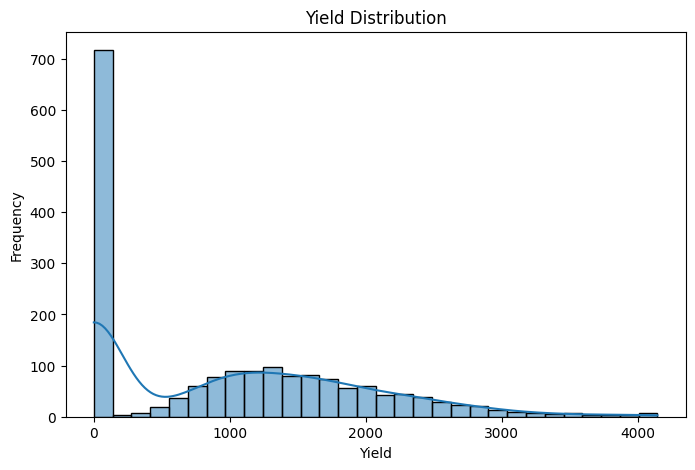

In [162]:
plt.figure(figsize=(8,5))

sns.histplot(df['yield_kg_per_ha'], bins=30, kde=True)

plt.title("Yield Distribution")

plt.xlabel("Yield")

plt.ylabel("Frequency")

plt.show()

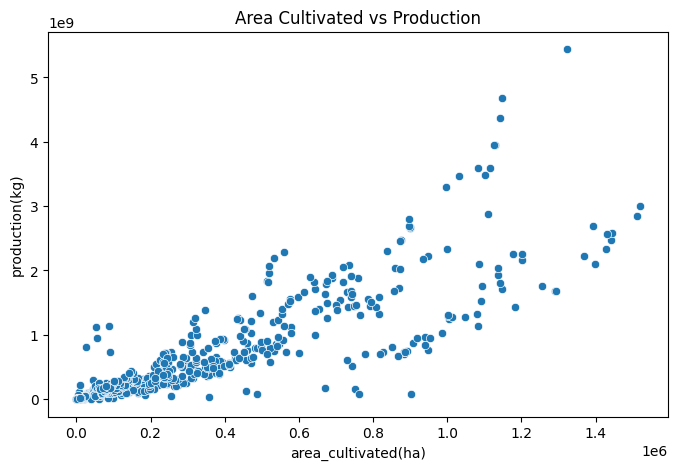

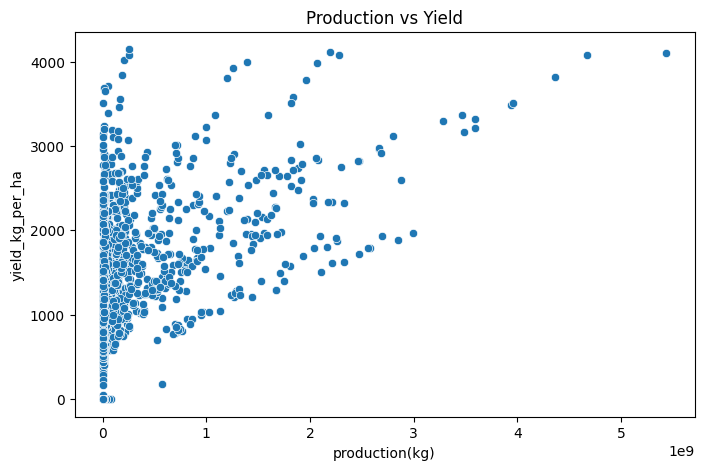

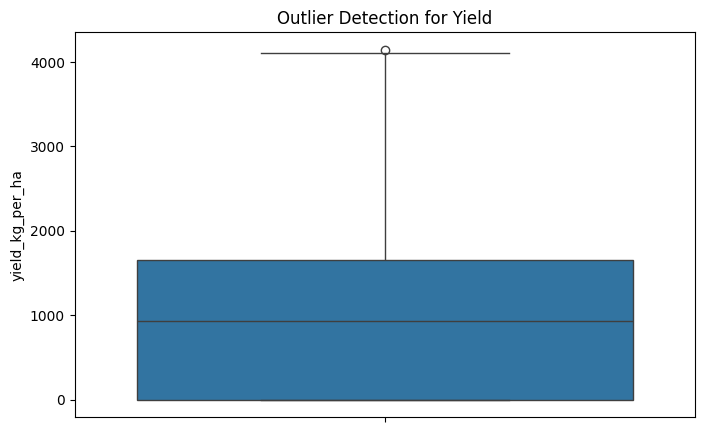

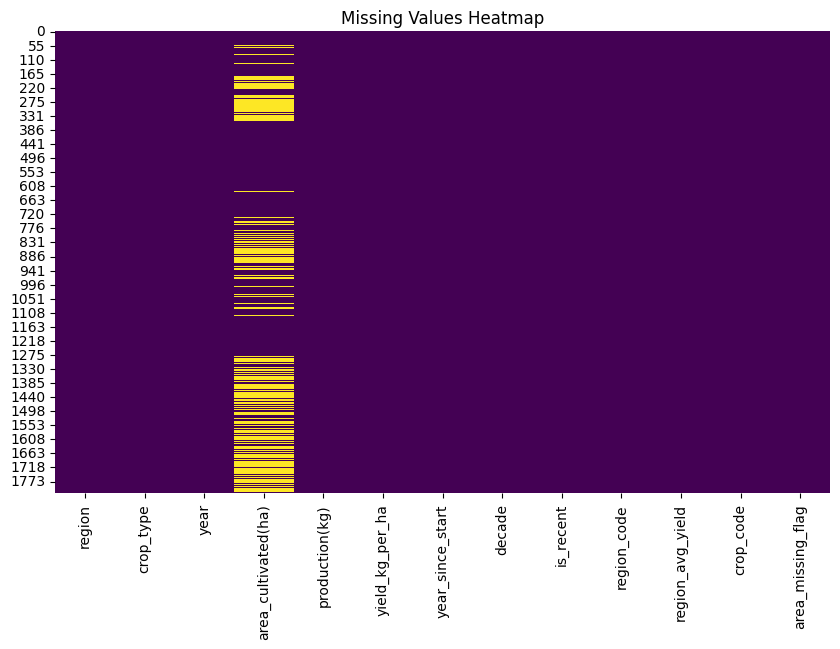

In [157]:
# Scatter Plot: Area vs Production
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='area_cultivated(ha)',
    y='production(kg)',
    data=df
)

plt.title("Area Cultivated vs Production")

plt.show()
# Scatter Plot: Production vs Yield
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='production(kg)',
    y='yield_kg_per_ha',
    data=df
)

plt.title("Production vs Yield")

plt.show()
# Outlier Detection Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(y=df['yield_kg_per_ha'])

plt.title("Outlier Detection for Yield")

plt.show()
# Missing Values Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis')

plt.title("Missing Values Heatmap")

plt.show()

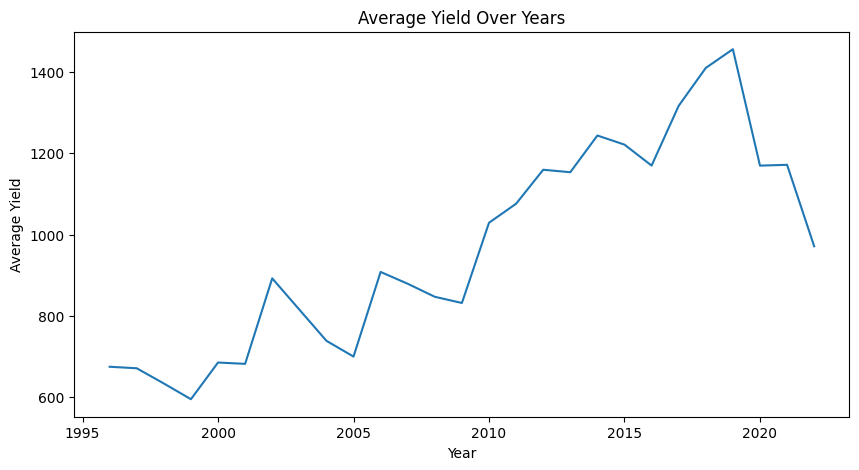

In [158]:
yearly_yield = df.groupby('year')['yield_kg_per_ha'].mean()

plt.figure(figsize=(10,5))

plt.plot(yearly_yield.index,
         yearly_yield.values)

plt.title("Average Yield Over Years")

plt.xlabel("Year")

plt.ylabel("Average Yield")

plt.show()

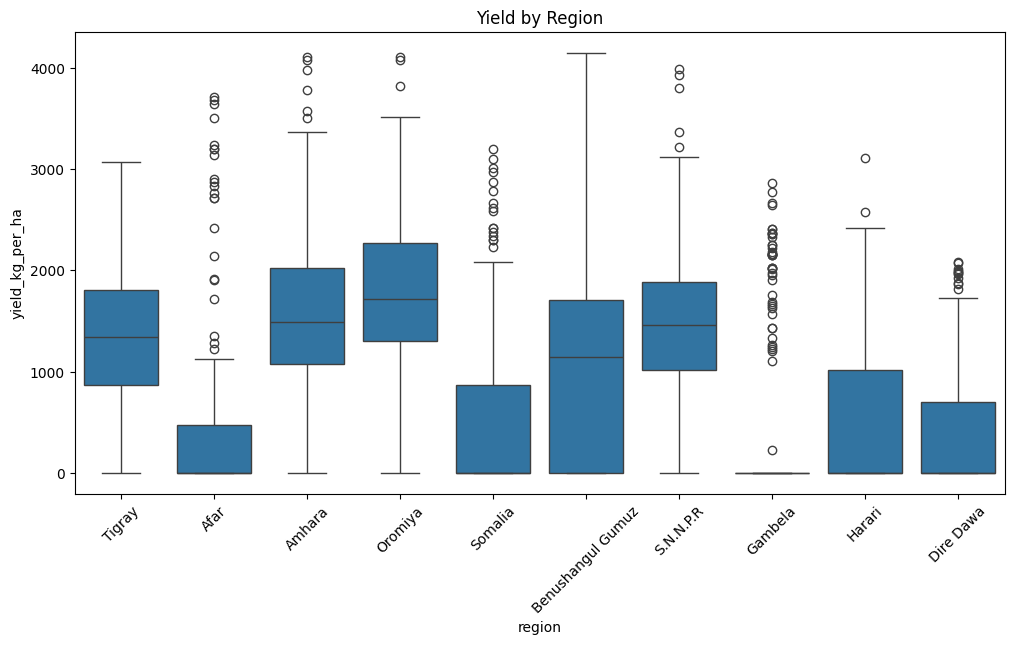

In [159]:
plt.figure(figsize=(12,6))

sns.boxplot(x='region',
            y='yield_kg_per_ha',
            data=df)

plt.title("Yield by Region")

plt.xticks(rotation=45)

plt.show()

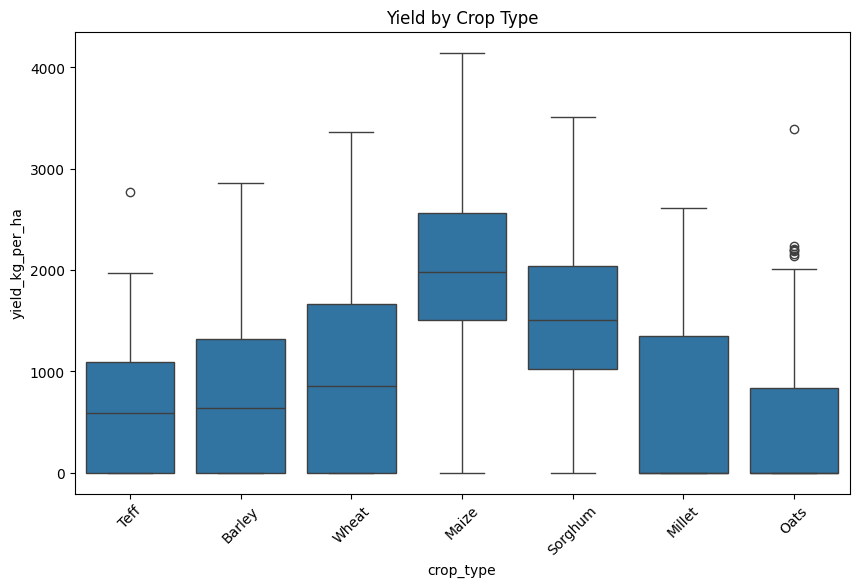

In [160]:
plt.figure(figsize=(10,6))

sns.boxplot(x='crop_type',
            y='yield_kg_per_ha',
            data=df)

plt.title("Yield by Crop Type")

plt.xticks(rotation=45)

plt.show()

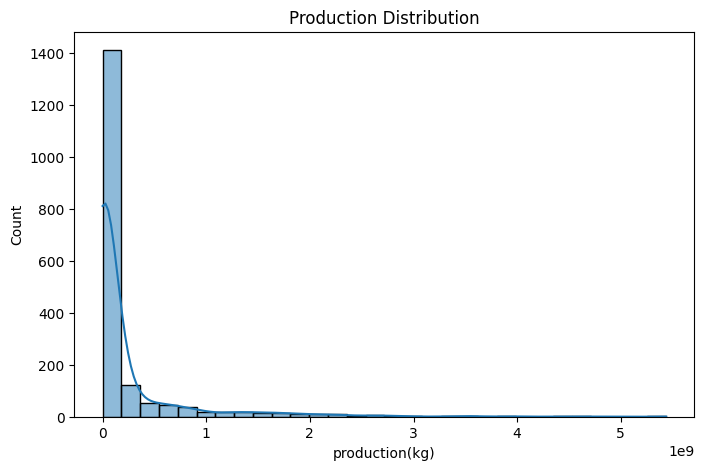

In [161]:
plt.figure(figsize=(8,5))

sns.histplot(df['production(kg)'], bins=30, kde=True)

plt.title("Production Distribution")

plt.show()

# Correlation Matrix

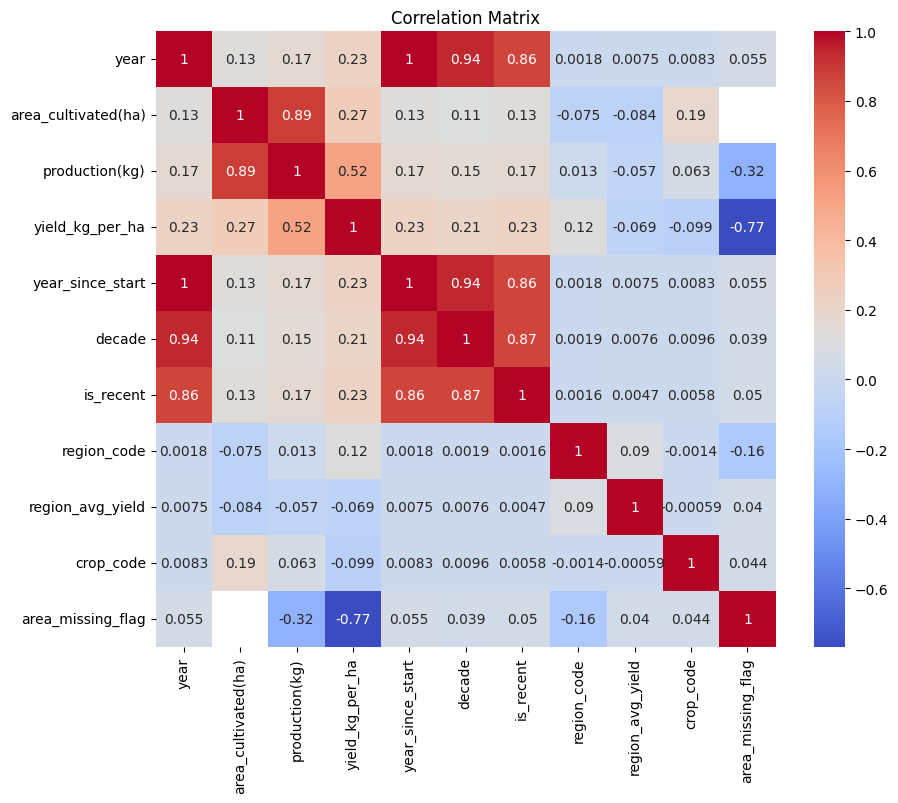

In [163]:
numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

# 13. Build Random Forest Model

In [145]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# 14. Create Pipeline

In [146]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

# 15. Train Model

In [147]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['year',
                                                   'area_cultivated(ha)',
                                                   'production(kg)']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['region', 'crop_type'])])),
                ('model',
                 RandomForestRegressor(max_depth=10, min_samples_leaf=2,
                                       min_samples_split=5, random_state=42))])

# 16. Make Predictions

In [148]:
train_pred = pipeline.predict(X_train)

test_pred = pipeline.predict(X_test)

# 17. Calculate R² Scores

In [149]:
train_r2 = r2_score(y_train, train_pred)

test_r2 = r2_score(y_test, test_pred)

print("Train R2:", train_r2)

print("Test R2:", test_r2)

Train R2: 0.9643282223584028
Test R2: 0.9148599836415836


# 18. Calculate RMSE

In [150]:
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))

test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("Train RMSE:", train_rmse)

print("Test RMSE:", test_rmse)

Train RMSE: 171.91653290633607
Test RMSE: 357.76066365170436


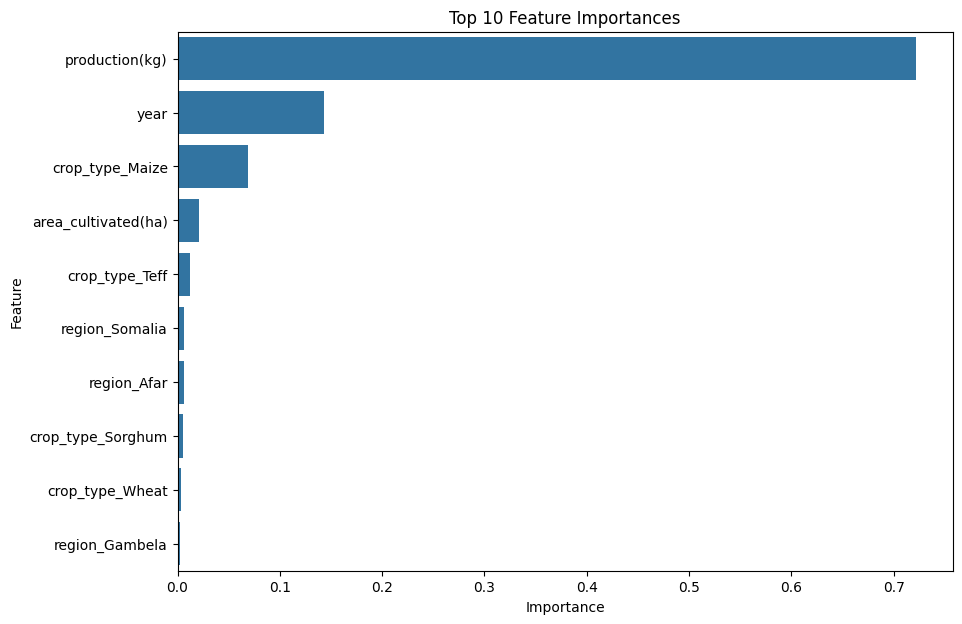

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# 19. Check Overfitting

In [151]:
difference = abs(train_r2 - test_r2)

print("R2 Difference:", difference)

if difference < 0.05:
    print("Good Generalization")

elif difference < 0.10:
    print("Slight Overfitting")

else:
    print("Strong Overfitting")

R2 Difference: 0.04946823871681916
Good Generalization


# 20. Cross Validation

In [152]:
cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("CV Scores:", cv_scores)

print("Average CV Score:", cv_scores.mean())

CV Scores: [0.79985558 0.74955796 0.75901786 0.91808555 0.89998476]
Average CV Score: 0.8253003436146736


# 21. Feature Importance

In [153]:
feature_names = (
    numerical_cols +
    list(
        pipeline.named_steps['preprocessor']
        .named_transformers_['cat']
        .named_steps['onehot']
        .get_feature_names_out(categorical_cols)
    )
)

importance = pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(10))

                Feature  Importance
2        production(kg)    0.721498
0                  year    0.142717
14      crop_type_Maize    0.068427
1   area_cultivated(ha)    0.020608
18       crop_type_Teff    0.012136
11       region_Somalia    0.006738
3           region_Afar    0.006516
17    crop_type_Sorghum    0.005022
19      crop_type_Wheat    0.002931
7        region_Gambela    0.002619
